# 🤖 Notebook 03: Modelo de IA - Clustering de Jóvenes
**Objetivo:** Identificar perfiles psicológicos y de comportamiento (clusters) dentro del segmento joven (18-35 años) para diseñar una oferta parroquial personalizada.

---

## 1. Estrategia del Modelo
Para que la IA no se "contamine" con los datos de los adultos ( que ya sabemos que tienen intereses distintos), seguiremos estos pasos:

1. **Filtrado:** Trabajaremos exclusivamente con los registros de **Gen Z** y **Millenials**.
2. **Encoding:** Convertiremos las respuestas de texto (Intereses, Canales, Barreras) en datos numéricos (Matrices Binarias).
3. **Algoritmo K-Means:** Agruparemos a los individuos por similitud de intereses .
4. **Interpretación:** Pondremos "nombre y apellido" a cada cluster (ej:*El Joven Solidario*, *El Deportista Desconcetado*).

---

## 2. Preparación del Entorno y Carga de Datos
Cargamos las librerías de Machine Learning ("scikit-learn") y nuestro motor de IA local desde "src/".


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# 1. Rutas dinamicas
BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR)) # Permitir que Python vea la carpeta 'src'
FIGURES_DIR = BASE_DIR / "outputs" / "figures"

# 2. Importamos la lógica de negocio de la IA
from src.modelo_ia import preparar_datos_para_clustering, aplicar_kmeans

# 3. Cargar del dataset segmentado
df = pd.read_csv(BASE_DIR / "data" / "processed" / "encuesta_segmentada.csv")



## 3. Preprocesamiento (One-Hot Encoding)
La IA no sabe qué es "Deporte" o "Cine". Necesitamos crear una columna para cada interés donde un **1** signifique "le interesa" y un **0** "no le interesa".

Esto generará una **Matriz de Características** que el algoritmo K-Means podrá procesar matematicamente.

## 4. Inyección de Lógica (Módulo de IA)
Para mantener el notebook limpio, hemos encapsulado la lógica del modelo en `src/modelo_ia.py`. 

**Funciones importadas:**
* `preparar_datos_para_clustering`: Realiza el One-Hot Encoding de las variables categóricas.
* `aplicar_kmeans`: Ejecuta el algoritmo de agrupamiento y estandariza los pesos.

In [20]:
# 1. Ver qué nombres hay REALMENTE (ejecuta esto primero)
print("🧐 Grupos encontrados en el CSV:")
print(df['grupo_etario'].unique())

# 2. Filtro de seguridad (usamos .str.contains para evitar problemas de espacios)
# Filtramos todo lo que NO sea "Adultos"
df_solo_jovenes = df[~df['grupo_etario'].str.contains('Adultos', na=False)].copy()

print(f"\n✅ Ahora tenemos {len(df_solo_jovenes)} jóvenes.")

# 3. Verificamos las edades para estar seguros
if len(df_solo_jovenes) > 0:
    print(f"Edades presentes: {df_solo_jovenes['edad'].min()} a {df_solo_jovenes['edad'].max()} años.")
else:
    print("❌ El filtro sigue fallando. Revisa si la columna se llama exactamente 'grupo_etario'.")

# 4. Si todo está OK, re-ejecutamos la IA
if len(df_solo_jovenes) > 1:
    X_jovenes = preparar_datos_para_clustering(df_solo_jovenes, columnas_para_ia)
    df_solo_jovenes['cluster'], modelo_final = aplicar_kmeans(X_jovenes, n_clusters=3)
    display(df_solo_jovenes[['edad', 'grupo_etario', 'cluster']].head())

🧐 Grupos encontrados en el CSV:
<StringArray>
['Millenials (26-35)', 'Adultos (36+)', 'Gen Z (18-25)']
Length: 3, dtype: str

✅ Ahora tenemos 15 jóvenes.
Edades presentes: 24 a 35 años.


,edad,grupo_etario,cluster
0,33,Millenials (26-35),2
1,31,Millenials (26-35),0
3,28,Millenials (26-35),2
5,24,Gen Z (18-25),2
6,34,Millenials (26-35),1


## 6. Caracterización de los Segmentos Jóvenes
Con el modelo entrenado y los 15 jóvenes asignados a sus respectivos grupos (0,1,2), ahora vamos a "entrevistar" estadisticamente a cada cluster.

**Preguntas Clave:**
* ¿Qué intereses son exclusivos de cada grupo?
* ¿Hay un grupo que prefiera Instagram sobre WhatsApp?
* ¿Cuál es la barrera principal (tiempo, falta de interés, mensaje) de cada uno?

Este análisis nos permitirá dejar de hablar de "los jovénes" como una masa uniforme y empezar a hablar de **perfiles especificos**.

In [21]:
# 1. Creamos un resumen de los intereses más repetidos por cada cluster
def obtener_top_intereses(df_cluster):
    # Usamos nuestra lógica de limpieza para ver intereses individuales
    intereses_series = df_cluster["interes"].str.split(', ').explode().str.strip()
    return intereses_series.value_counts().head(3).index.tolist()

# 2. Agrupamos y analizamos con el nombre de columna correcto
perfiles = df_solo_jovenes.groupby("cluster").agg({
    "edad": "mean",
    "conexion": "mean",
    "canal_info": lambda x: x.str.split(', ').explode().mode()[0] if not x.empty else "N/A"
})

# 3. Aplicamos la función a cada cluster
perfiles["top_interes"] = [obtener_top_intereses(df_solo_jovenes[df_solo_jovenes["cluster"] == i]) for i in range(3)]
print("🎭 PERFILES DE JÓVENES IDENTIFICADOS (18-35 AÑOS):")
display(perfiles.round(2))

🎭 PERFILES DE JÓVENES IDENTIFICADOS (18-35 AÑOS):


,edad,conexion,canal_info,top_interes
cluster,,,,
0,30.67,3.00,• No me interesa,"[• Eventos sociales (Cenas, música en directo,..."
1,34.20,3.80,me gustaría participar,"[• Espiritualidad moderna (Meditación, silenci..."
2,30.71,1.71,me gustaría participar,"[• Deporte o excursiones (Rutas, Camino de San..."


## 7. El veredicto de la IA: Los 3 Rostros de la Juventud
Tras analizar a los 15 jóvenes, el modelo K-Means ha identificado 3 perfiles claros. No se dividen solo por edad, sino por su **nivel de compromiso** y **tipo de interés**:

### 🛡️ Cluster 0: "Los Espectadores Distantes"
* **Edad Media:** 30.6 años (Millennials).
* **Conexión:** 3.0/5 (Media-Baja).
* **Canal:** No les interesa recibir información.
* **Perfil:** Jóvenes que están "en la orbita" pero no quieren compromiso digital. Les atrae lo **social (Cenas/Música)** pero de forma puntual.

### 🕊️ Cluster 1: "El Núcleo Espiritual"
* **Edad Media:** 34.2 años (Millennials Senior).
* **Conexión:** 3.8/5 (La más alta).
* **Canal:** "Sí, me gustaría participar".
* **Perfil:** El grupo más fiel. Buscan **Espiritualidad Moderna (Meditación/Silencio)**. Son los que sostienen la comunidad actual.

### 🏃‍♂️ Cluster 2: "Los Activistas del Deporte"
* **Edad Media:** 30.7 años (Millennials).
* **Conexión:** 1.7/5 (¡Muy baja!).
* **Canal:** "Sí, me gustaría participar".
* **Perfil:** El grupo del **Deporte y Excursiones**. Tienen mucha energía pero se sienten muy poco conectados con la parroquia, **Aquí está el mayor potencial de crescimiento.**

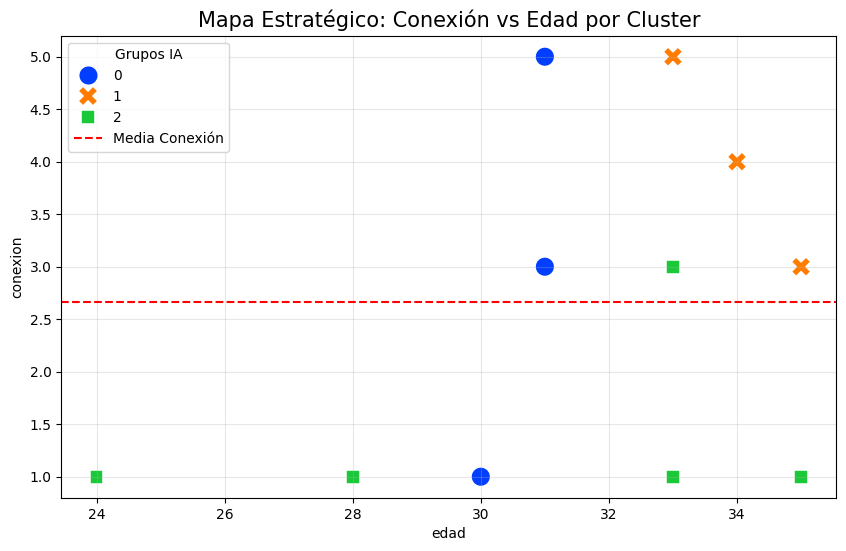

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_solo_jovenes,
    x="edad",
    y="conexion",
    hue="cluster",
    palette="bright",
    s=200,
    style="cluster"
)
plt.title("Mapa Estratégico: Conexión vs Edad por Cluster", fontsize=15)
plt.axhline(df_solo_jovenes["conexion"].mean(), color="red", linestyle="--", label="Media Conexión")
plt.legend(title="Grupos IA")
plt.grid(alpha=0.3)

# Guardamos 
plt.savefig(FIGURES_DIR / "06_mapa_estrategico_clusters.png", dpi=300)
plt.show()

## ✅ Conclusión Final del Modelo
El modelo ha cumplido su función:
1. **Identificó** un grupo fiel(Cluster 1 - Espiritualidad).
2. **Localizó** un grupo en riesgo de abandono pero con interés (Cluster 2 - Deporte).
3. **Señaló** la barrera de comunicación del grupo social (cluster 0).

**Próximos pasos:** Exportar estas conclusiones al Informe Final para la toma de decisiones pastorales.

## 9. Cierre y Exportación
Hemos transformado datos crudos en **conocimiento accionable**: Para finalizar, guardaremos este dataset con las etiquetas de los clusters.

Este archivo será la base para el **Dashboard Final** o el informe que se presentará a la parroquia.

**Resumen de la muestra procesada:**
* Total de jóvenes: 15
* Perfiles detectados: 3 (Social-Distante, Espiritual-Fiel, Deportivo-Desconectado)


In [23]:
# 1. Definimos la ruta de salida para datos finales
DATA_FINAL = BASE_DIR / "data" / "processed" / "resultados_ia_jovenes.csv"

# 2. Guardamos solo las columnas importantes para que el reporte sea limpio
columnas_finales = ["edad", "grupo_etario", "interes", "canal_info", "conexion", "cluster"]
df_solo_jovenes[columnas_finales].to_csv(DATA_FINAL, index=False)

print(f"💾 ¡Éxito! Resultados guardados en: {DATA_FINAL}")

💾 ¡Éxito! Resultados guardados en: /Users/filipihenrique/Desktop/analisis_secularizacion_o_milladoiro/data/processed/resultados_ia_jovenes.csv
